# Lecture 08 – Clasificación con Red Neuronal Profunda (DNN)
### Universidad EAFIT | Artificial Intelligence

---

## Contexto: ¿Por qué Deep Learning?

En el **Machine Learning tradicional**, un experto diseña las features manualmente antes de entrenar el modelo. En **Deep Learning**, la red aprende esas features directamente de los datos crudos, capa a capa:

```
ML Tradicional : Raw Input → Feature Engineering (humano) → Modelo → Output
Deep Learning  : Raw Input → DNN (aprende representaciones) ────────> Output
```

Como vimos en clase, cada neurona de la capa $k$ calcula:

$$z_i^{(k)} = g\!\left(\sum_j W_{ij}^{(k)} \cdot z_j^{(k-1)}\right)$$

donde $g$ es la función de activación no-lineal. Sin esa no-linealidad, apilar capas no añadiría capacidad expresiva.

---

## PyTorch vs Keras — ¿Cuándo usar cada uno?

| | **PyTorch** | **Keras (TensorFlow)** |
|--|------------|------------------------|
| **Nivel de abstracción** | Bajo — control total del training loop | Alto — API declarativa y concisa |
| **Ideal para** | Investigación, architecturas custom | Prototipado rápido, producción |
| **Training loop** | Manual (zero_grad / backward / step) | Automático (`model.fit`) |
| **Curva de aprendizaje** | Mayor | Menor |

> En `MyfirstDeepNN.ipynb` construimos el training loop **a mano en PyTorch** para entender cada paso. Aquí usamos **Keras** para ver cómo la misma lógica se expresa de forma más compacta, sin perder la comprensión conceptual.

---

## ¿Qué construiremos en este notebook?

Aplicaremos una DNN para clasificar las 10 categorías de prendas de vestir del dataset **Fashion MNIST**. También incluye una sección de **CNN** para comparar ambos enfoques.

| Sección | Contenido |
|---------|----------|
| 1 | Setup e imports |
| 2 | Fashion MNIST: carga y visualización |
| 3 | Preprocesamiento (split + normalización) |
| 4 | Definición del modelo DNN con Keras |
| 5 | Compilación: loss, optimizador, métricas |
| 6 | Entrenamiento y curvas de aprendizaje |
| 7 | Evaluación y matriz de confusión |
| 8 | *(Extra)* Red Neuronal Convolucional (CNN) |

---

## 0. Configuración del Entorno

Importamos las librerías necesarias:

- **NumPy / Matplotlib**: operaciones numéricas y visualización
- **scikit-learn**: utilidades para split de datos y métricas (matriz de confusión)
- **TensorFlow / Keras**: framework de Deep Learning para construir y entrenar la red

> **Keras** es la API de alto nivel de TensorFlow. Permite definir, compilar y entrenar redes neuronales con muy pocas líneas de código, ocultando los detalles del training loop que implementamos manualmente en PyTorch.

In [2]:
import numpy as np                              # Operaciones matriciales y numéricas
from matplotlib import pyplot as plt            # Visualización de datos y gráficas

from sklearn.datasets import fetch_openml       # Descarga de datasets desde OpenML
from sklearn.model_selection import train_test_split  # División estratificada de datos
from sklearn.metrics import confusion_matrix    # Matriz de confusión para evaluar el modelo

from tensorflow import keras                    # API de alto nivel de TensorFlow

# Semilla aleatoria para reproducibilidad: garantiza que los splits y la
# inicialización de pesos sean iguales en cada ejecución.
random_state = 24

# Configuración estética de las gráficas
plt.rc('font', family='serif', size=12)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


---
## 1. El Dataset: Fashion MNIST

**Fashion MNIST** es un dataset creado por Zalando Research como reemplazo más desafiante del MNIST clásico. Contiene:

- **70,000 imágenes** de prendas de vestir en escala de grises
- **28×28 píxeles** por imagen → **784 features** de entrada (mismo formato que MNIST)
- **10 categorías**: camiseta, pantalón, suéter, vestido, chaqueta, sandalia, camisa, zapatilla, bolso, bota

<img src='https://github.com/zalandoresearch/fashion-mnist/raw/master/doc/img/fashion-mnist-sprite.png' alt='Fashion-MNIST sample' width='600'/>

### ¿Por qué Fashion MNIST en lugar de MNIST?

El MNIST de dígitos es demasiado fácil para las redes modernas (>99% accuracy). Fashion MNIST presenta mayor variabilidad visual entre clases, lo que lo hace más representativo de problemas de clasificación reales y permite apreciar mejor el impacto de la arquitectura.

### Representación de los datos

Al igual que en el notebook de PyTorch, cada imagen se representa como un **vector de 784 valores** (pixels aplanados de 0 a 255). La red neuronal FC recibe ese vector como entrada. Como veremos en la sección de CNN, esta representación plana **pierde la estructura espacial 2D** — uno de los argumentos centrales para las CNNs que discutimos en clase.

In [3]:
# Descargamos Fashion MNIST desde OpenML (repositorio público de datasets de ML).
# return_X_y=True devuelve directamente (features, etiquetas) sin empaquetar en un objeto.
# as_frame=False devuelve arrays NumPy en lugar de DataFrames de pandas.
X, y = fetch_openml(
    'Fashion-MNIST',
    version='active',
    return_X_y=True,
    as_frame=False
)

# Las etiquetas llegan como strings ('0', '1', ..., '9').
# Las convertimos a enteros de 8 bits para compatibilidad con Keras.
y = y.astype('int8')

print(f'Shape de X (features) : {X.shape}  → (muestras, pixels)')
print(f'Shape de y (etiquetas) : {y.shape}')
print(f'Rango de valores de X  : [{X.min():.0f}, {X.max():.0f}]  → pixeles sin normalizar')
print(f'Clases únicas          : {sorted(set(y))}')

Shape de X (features) : (70000, 784)  → (muestras, pixels)
Shape de y (etiquetas) : (70000,)
Rango de valores de X  : [0, 255]  → pixeles sin normalizar
Clases únicas          : [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9)]


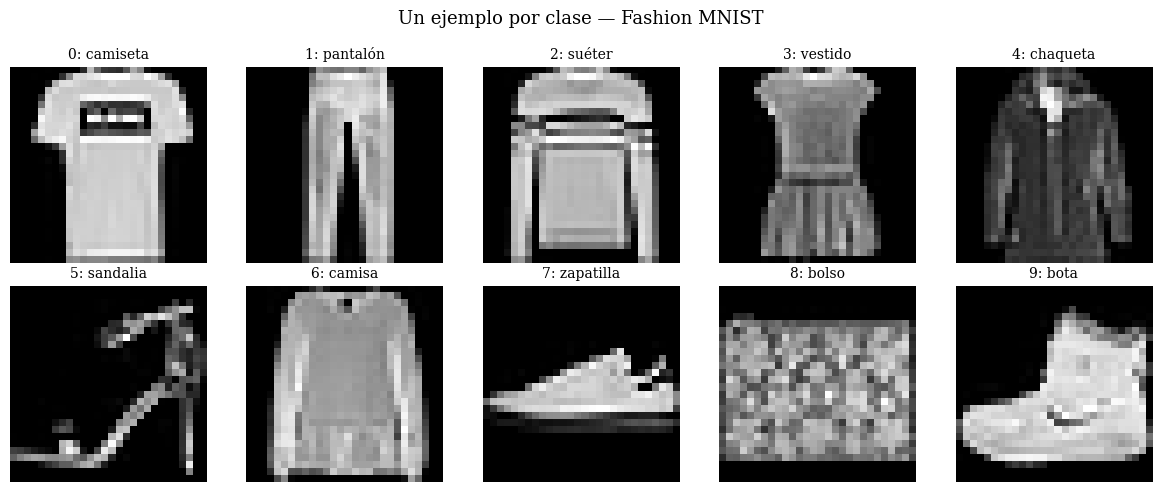

In [4]:
# Diccionario que mapea el índice numérico a la categoría de prenda.
# Útil para interpretar las predicciones del modelo en términos legibles.
classes = {
    0: 'camiseta',
    1: 'pantalón',
    2: 'suéter',
    3: 'vestido',
    4: 'chaqueta',
    5: 'sandalia',
    6: 'camisa',
    7: 'zapatilla',
    8: 'bolso',
    9: 'bota'
}

# Visualizamos una cuadrícula 4×5 con ejemplos de cada clase
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
shown = {}
for img, label in zip(X, y):
    if label not in shown:
        ax = axes[label // 5, label % 5]
        ax.imshow(img.reshape(28, 28), cmap='gray')   # Reformateamos el vector (784,) a (28,28)
        ax.set_title(f'{label}: {classes[label]}', fontsize=10)
        ax.axis('off')
        shown[label] = True
    if len(shown) == 10:
        break
plt.suptitle('Un ejemplo por clase — Fashion MNIST', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Preprocesamiento de Datos

### División Train / Validation / Test

A diferencia del notebook de PyTorch (donde solo usamos train/test), aquí dividimos en **tres conjuntos**:

| Conjunto | Tamaño | Uso |
|----------|--------|-----|
| **Train** | 50,000 | Ajustar los pesos de la red (backpropagation) |
| **Validation** | 10,000 | Monitorear el rendimiento **durante** el entrenamiento (detectar overfitting) |
| **Test** | 10,000 | Evaluar el rendimiento **final** del modelo (datos nunca vistos) |

> **¿Por qué separar validación de prueba?** El conjunto de validación se usa en cada época para ajustar decisiones de diseño (hiperparámetros, arquitectura). Si usáramos el conjunto de prueba para eso, estaríamos introduciendo *information leakage*: el modelo habría sido indirectamente optimizado para ese conjunto, y su accuracy ya no sería una estimación honesta de generalización.

### Normalización

Los píxeles tienen valores enteros de **0 a 255**. Dividimos entre 255 para escalarlos al rango **[0, 1]**.

Esto es fundamental porque:
- Los optimizadores (Adam, SGD) funcionan mejor cuando las features tienen magnitudes similares y pequeñas
- Evita que los gradientes sean demasiado grandes o pequeños durante el backpropagation
- Las funciones de activación como tanh y sigmoid operan de forma más efectiva en este rango

Usar `stratify=y` garantiza que la **proporción de clases** sea igual en todos los conjuntos (importante cuando las clases no están perfectamente balanceadas).

In [5]:
# División estratificada: 50,000 train / 10,000 val / 10,000 test
# stratify=y: mantiene la proporción de cada clase en ambos subconjuntos
# random_state: fija la semilla para reproducibilidad
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=20000, stratify=y, random_state=random_state
)
# De los 20,000 de val+test, tomamos 10,000 como prueba final
X_val, X_test, y_val, y_test = train_test_split(
    X_val, y_val, test_size=10000, stratify=y_val, random_state=random_state
)

# Normalización: escalamos de [0, 255] a [0.0, 1.0]
# Aplicamos la MISMA transformación (÷255) a los tres conjuntos.
# IMPORTANTE: nunca calcular estadísticas de normalización sobre val/test.
X_train = X_train / 255
X_val   = X_val   / 255
X_test  = X_test  / 255

print(f'Conjunto de entrenamiento : {X_train.shape[0]:>6,} muestras')
print(f'Conjunto de validación    : {X_val.shape[0]:>6,} muestras')
print(f'Conjunto de prueba        : {X_test.shape[0]:>6,} muestras')
print(f'Rango de X_train tras normalización: [{X_train.min():.1f}, {X_train.max():.1f}]')

Conjunto de entrenamiento : 50,000 muestras
Conjunto de validación    : 10,000 muestras
Conjunto de prueba        : 10,000 muestras
Rango de X_train tras normalización: [0.0, 1.0]


---
## 3. Definición del Modelo DNN con Keras

### API Sequential de Keras

Keras ofrece la API `Sequential` para apilar capas en orden. Es equivalente a la clase `FCNeuralNetwork` que definimos en PyTorch, pero más concisa:

```python
# PyTorch (manual)                  # Keras (declarativo)
class FCNet(nn.Module):              model = keras.Sequential([
    def __init__(self):                  Dense(128, activation='tanh'),
        self.l1 = Linear(784, 128)       Dense(64,  activation='tanh'),
        self.l2 = Linear(128, 10)        Dense(10,  activation='softmax'),
    def forward(self, x):            ])
        x = relu(self.l1(x))
        return self.l2(x)
```

### Arquitectura de esta red

```
Input(784) → Dense(128, tanh) → Dense(64, tanh) → Dense(64, tanh) → Dense(32, tanh) → Dense(10, softmax)
```

Esta es una DNN con **4 capas ocultas** — más profunda que la de PyTorch (1 capa oculta). Con mayor profundidad, la red puede aprender representaciones más abstractas, pero también es más propensa al overfitting.

### Función de Activación: tanh

A diferencia del notebook de PyTorch donde usamos ReLU, aquí usamos **tanh** en las capas ocultas:

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} \in (-1, 1)$$

| | ReLU | tanh |
|--|------|------|
| Rango | [0, ∞) | (-1, 1) |
| Centrada en 0 | No | Sí |
| Saturación | Solo en negativos | En ambos extremos |
| Vanishing gradient | Menos propenso | Más propenso en redes muy profundas |

### Regularización L2

Con 4 capas ocultas y muchos parámetros, el riesgo de **overfitting** es alto. La regularización L2 añade una penalización a la función de pérdida proporcional al cuadrado de los pesos:

$$\mathcal{L}_{\text{reg}} = \mathcal{L}_{\text{CE}} + \lambda \sum_i w_i^2$$

Esto desincentivar pesos muy grandes, forzando al modelo a ser más "conservador" y generalizando mejor a datos nuevos. Como vimos en clase, esto es una forma de **early stopping implícito** sobre la magnitud de los parámetros.

---

In [6]:
# Definimos el modelo con la API Sequential de Keras.
# Cada keras.layers.Dense es una capa fully-connected: equivalente a nn.Linear en PyTorch.
model = keras.Sequential([

    # Capa 1: 128 neuronas, entrada de 784 features (28x28 píxeles aplanados)
    # kernel_regularizer=l2(0.001): penaliza pesos grandes con λ=0.001
    keras.layers.Dense(
        128,
        input_shape=(784,),             # Define implícitamente la capa de entrada
        activation='tanh',              # Activación no-lineal: tanh(x) = (e^x - e^-x)/(e^x + e^-x)
        kernel_regularizer=keras.regularizers.l2(0.001)  # Regularización L2: evita overfitting
    ),

    # Capa 2: 64 neuronas — la red comprime la representación
    keras.layers.Dense(
        64,
        activation='tanh',
        kernel_regularizer=keras.regularizers.l2(0.001)
    ),

    # Capa 3: otra capa de 64 neuronas — más profundidad = más capacidad expresiva
    keras.layers.Dense(
        64,
        activation='tanh',
        kernel_regularizer=keras.regularizers.l2(0.001)
    ),

    # Capa 4: 32 neuronas — seguimos comprimiendo hacia la representación final
    keras.layers.Dense(
        32,
        activation='tanh',
        kernel_regularizer=keras.regularizers.l2(0.002)  # Lambda más alto: mayor regularización
    ),

    # Capa de salida: 10 neuronas (una por clase), activación Softmax
    # Softmax convierte los logits en probabilidades que suman 1:
    # P(y_k | x) = exp(z_k) / Σ_j exp(z_j)
    # Nota: en PyTorch dejamos esto a CrossEntropyLoss; en Keras lo ponemos explícitamente
    keras.layers.Dense(
        10,
        activation='softmax',
        kernel_regularizer=keras.regularizers.l2(0.01)   # Mayor λ en la salida
    ),
])

# model.summary() imprime: nombre de capa, shape de salida y número de parámetros
model.summary()

c:\Users\yomin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,306 (450.41 KB)

 Trainable params: 115,306 (450.41 KB)

 Non-trainable params: 0 (0.00 B)

---
## 4. Compilación del Modelo

En Keras, **compilar** un modelo significa configurar tres elementos que en PyTorch definimos por separado:

| Elemento | Keras | PyTorch equivalente |
|---------|-------|--------------------|
| Función de pérdida | `loss=...` | `criterion = nn.CrossEntropyLoss()` |
| Optimizador | `optimizer=...` | `optimizer = torch.optim.Adam(...)` |
| Métricas | `metrics=[...]` | Calculado manualmente en el loop |

### Función de pérdida: `sparse_categorical_crossentropy`

Es la Cross-Entropy para clasificación multi-clase cuando las etiquetas son **enteros** (no one-hot vectors). Internamente calcula:

$$\mathcal{L} = -\log P(y^* \mid \mathbf{x}) = -\log \frac{e^{z_{y^*}}}{\sum_k e^{z_k}}$$

Es equivalente a `CrossEntropyLoss` de PyTorch (que ya incluía Softmax internamente). La diferencia es que aquí pusimos `softmax` explícitamente en la capa de salida, por lo que usamos `categorical_crossentropy` sobre probabilidades, no logits.

> **`sparse_`** indica que las etiquetas son enteros escalares (0, 1, ..., 9) en lugar de vectores one-hot [0,0,1,0,...,0]. Keras maneja ambos formatos.

### Optimizador: Adam

Usamos **Adam** con `learning_rate=0.0005` — un poco más conservador que el 0.001 del notebook de PyTorch, lo que tiene sentido dado que entrenamos por más épocas (100 vs 10).

In [7]:
# model.compile() configura el proceso de entrenamiento.
# Este paso es el equivalente a definir criterion + optimizer en PyTorch.
model.compile(

    # Optimizador Adam con learning rate personalizado.
    # Adam adapta el lr individualmente para cada parámetro usando momentos del gradiente.
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),

    # Función de pérdida para clasificación multi-clase con etiquetas enteras.
    # Equivalente a nn.CrossEntropyLoss() de PyTorch.
    loss='sparse_categorical_crossentropy',

    # Métricas adicionales a monitorear durante el entrenamiento.
    # No afectan el entrenamiento, solo se calculan para visualización.
    metrics=['accuracy']
)

print('Modelo compilado exitosamente.')
print(f'Optimizador : Adam  (lr = 0.0005)')
print(f'Loss        : sparse_categorical_crossentropy')

Modelo compilado exitosamente.
Optimizador : Adam  (lr = 0.0005)
Loss        : sparse_categorical_crossentropy


---
## 5. Entrenamiento del Modelo

### `model.fit()` vs el training loop manual

En PyTorch implementamos explícitamente:
```
zero_grad() → forward() → loss() → backward() → optimizer.step()
```

En Keras, `model.fit()` encapsula **todo ese ciclo automáticamente** en una sola llamada:

```python
model.fit(X_train, y_train, batch_size=..., epochs=..., validation_data=(X_val, y_val))
```

Internamente Keras:
1. Divide `X_train` en mini-batches de tamaño `batch_size`
2. Para cada batch ejecuta: forward → loss → backward → update
3. Al final de cada epoch evalúa sobre `validation_data`
4. Almacena el historial de métricas en `model.history`

### Hiperparámetros de entrenamiento

- **`batch_size=1024`**: batch más grande que en PyTorch (64). Con más datos por batch el gradiente es más preciso, pero requiere más memoria. Es viable aquí porque no usamos GPU dedicada con memoria limitada.
- **`epochs=100`**: entrenamos por muchas más épocas. Las curvas de validación nos dirán si el modelo empieza a hacer overfitting.

### Overfitting y las curvas de aprendizaje

Como vimos en clase, un modelo con muchos parámetros tiende a memorizar los datos de entrenamiento. Las señales de overfitting en las curvas son:
- La **loss de entrenamiento** sigue bajando
- La **loss de validación** se estanca o sube
- La **accuracy de validación** se estanca o baja

La regularización L2 que definimos en las capas combate este fenómeno.

In [8]:
%%time
# model.fit() ejecuta el ciclo completo de entrenamiento.
# Internamente: para cada epoch → divide en mini-batches → forward → loss → backward → update
history_obj = model.fit(
    X_train,                          # Features de entrenamiento (50,000 × 784)
    y_train,                          # Etiquetas de entrenamiento (50,000,)
    batch_size=1024,                  # Ejemplos por mini-batch
    epochs=100,                       # Pasadas completas por el dataset
    validation_data=(X_val, y_val),   # Evaluación al final de cada epoch (no para entrenar)
    verbose=1                         # Muestra progreso por epoch
)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6401 - loss: 1.8142 - val_accuracy: 0.7672 - val_loss: 1.4010
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7930 - loss: 1.2802 - val_accuracy: 0.8174 - val_loss: 1.1809
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8255 - loss: 1.1353 - val_accuracy: 0.8317 - val_loss: 1.0887
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8385 - loss: 1.0601 - val_accuracy: 0.8427 - val_loss: 1.0338
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8439 - loss: 1.0104 - val_accuracy: 0.8504 - val_loss: 0.9893
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8519 - loss: 0.9685 - val_accuracy: 0.8556 - val_loss: 0.9516
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8560 - loss: 0.9344 - val_accuracy: 0.8578 - val_loss: 0.9213
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8583 - loss: 0.9057 - val_accuracy: 0.8625 - 

---
## 6. Curvas de Aprendizaje

Las **curvas de aprendizaje** muestran cómo evolucionan la pérdida y el accuracy en entrenamiento y validación a lo largo de las épocas.

### ¿Cómo interpretar las curvas?

```
                 Underfitting          Bien ajustado         Overfitting
Train loss:      alta y estacionaria   baja                  muy baja
Val loss:        alta y estacionaria   baja y similar train  sube mientras train baja
```

- Si **val_loss sube** mientras **train_loss baja** → overfitting
- Si **ambas losses son altas** → underfitting (modelo muy simple o poco entrenamiento)
- **Gap entre train y val**: siempre habrá algo de diferencia, pero un gap pequeño indica buena generalización

La regularización L2 que configuramos debería reducir el gap entre train y validation.

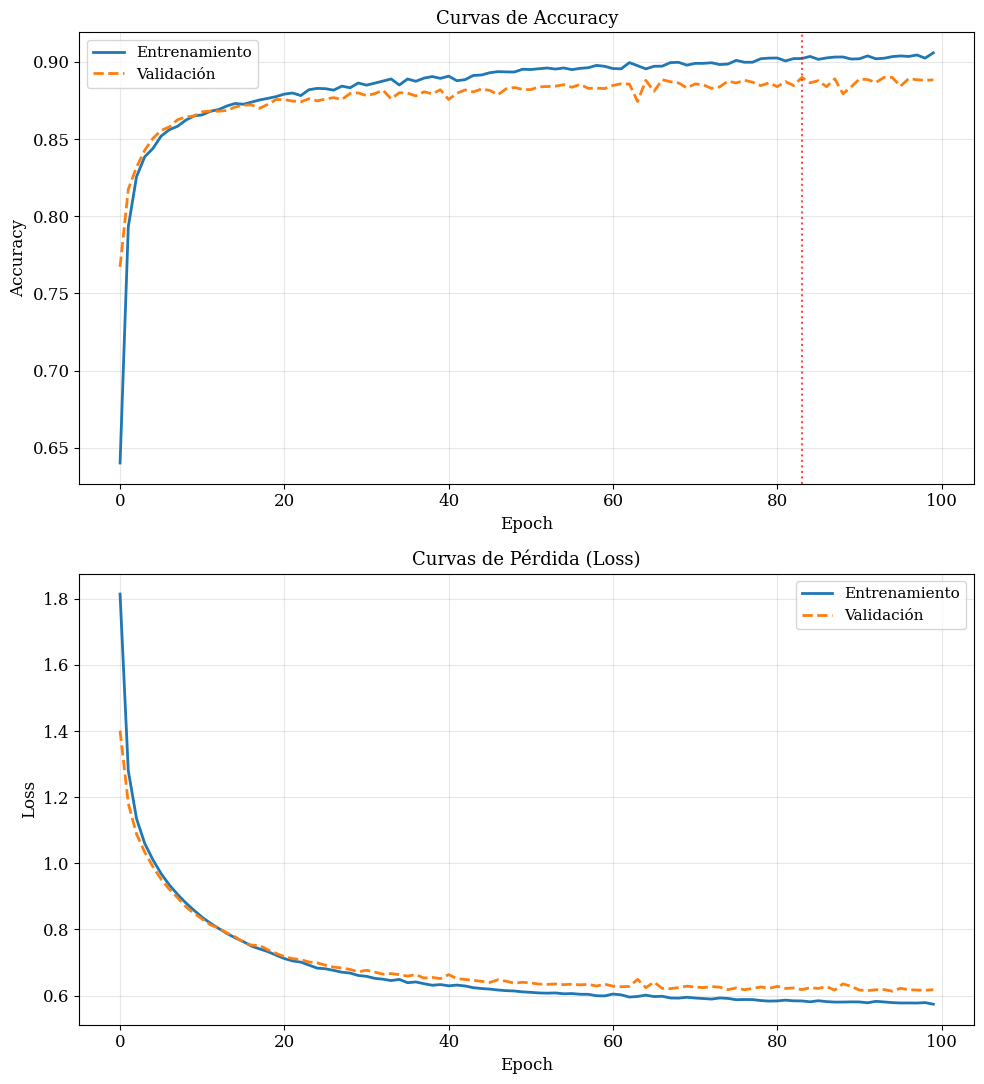

Mejor val_accuracy: 0.8899 en epoch 83


In [9]:
# Extraemos el historial de métricas almacenado por Keras durante el entrenamiento.
# model.history.history es un dict con claves: 'loss', 'accuracy', 'val_loss', 'val_accuracy'
history = model.history.history

fig, ax = plt.subplots(2, 1, figsize=(10, 11))

# --- Gráfica superior: Accuracy ---
ax[0].set_xlabel('Epoch', size=12)
ax[0].set_ylabel('Accuracy', size=12)
ax[0].set_title('Curvas de Accuracy', size=13)
ax[0].plot(history['accuracy'],     label='Entrenamiento', linewidth=2)
ax[0].plot(history['val_accuracy'], label='Validación',    linewidth=2, linestyle='--')
ax[0].legend(fontsize=11)
ax[0].grid(True, alpha=0.3)
# Señalamos la época con mejor accuracy de validación
best_epoch = history['val_accuracy'].index(max(history['val_accuracy']))
ax[0].axvline(best_epoch, color='red', linestyle=':', alpha=0.7, label=f'Mejor val (epoch {best_epoch})')

# --- Gráfica inferior: Loss ---
ax[1].set_xlabel('Epoch', size=12)
ax[1].set_ylabel('Loss', size=12)
ax[1].set_title('Curvas de Pérdida (Loss)', size=13)
ax[1].plot(history['loss'],     label='Entrenamiento', linewidth=2)
ax[1].plot(history['val_loss'], label='Validación',    linewidth=2, linestyle='--')
ax[1].legend(fontsize=11)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Mejor val_accuracy: {max(history["val_accuracy"]):.4f} en epoch {best_epoch}')

---
## 7. Evaluación Final y Matriz de Confusión

### Evaluación sobre el conjunto de prueba

`model.evaluate()` es el equivalente al loop de evaluación que escribimos manualmente en PyTorch (con `model.eval()` y `torch.no_grad()`). Keras deshabilita el entrenamiento automáticamente.

### Matriz de Confusión

La accuracy global es una métrica resumida. La **matriz de confusión** nos dice:
- Qué clases se predicen correctamente (diagonal)
- Qué clases se confunden entre sí (fuera de la diagonal)

$$CM_{ij} = \text{número de veces que la clase } i \text{ fue predicha como clase } j$$

Por ejemplo, es esperable que el modelo confunda:
- `camiseta` (0) con `camisa` (6) — visualmente similares
- `suéter` (2) con `chaqueta` (4) — misma silueta
- `sandalia` (5) con `zapatilla` (7) o `bota` (9) — todos son calzado

Una matriz de confusión con pocos errores fuera de la diagonal y patrones de confusión visualmente razonables indica que el modelo ha aprendido representaciones con sentido.

In [10]:
# model.evaluate() calcula la pérdida y accuracy sobre el conjunto de prueba.
# Equivalente al loop: for batch in test_loader: outputs = model(x); acc += (pred==y).sum()
print('--- Evaluación sobre el conjunto de PRUEBA ---')
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f'\nAccuracy final en prueba: {test_acc:.4f}  ({test_acc*100:.2f}%)')

--- Evaluación sobre el conjunto de PRUEBA ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8825 - loss: 0.6286  

Accuracy final en prueba: 0.8825  (88.25%)


In [11]:
# Generamos las predicciones para el conjunto de prueba.
# model.predict() devuelve probabilidades Softmax para cada clase: shape (10000, 10)
# np.argmax(..., axis=-1) selecciona la clase con mayor probabilidad: shape (10000,)
y_pred = np.argmax(model.predict(X_test), axis=-1)

print(f'Primeras 10 predicciones : {y_pred[:10]}')
print(f'Primeras 10 etiquetas    : {y_test[:10]}')
print(f'Correspondencia          : {[classes[p] for p in y_pred[:10]]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step
Primeras 10 predicciones : [5 2 9 9 5 9 4 5 0 3]
Primeras 10 etiquetas    : [5 2 9 9 5 9 4 5 0 3]
Correspondencia          : ['sandalia', 'suéter', 'bota', 'bota', 'sandalia', 'bota', 'chaqueta', 'sandalia', 'camiseta', 'vestido']


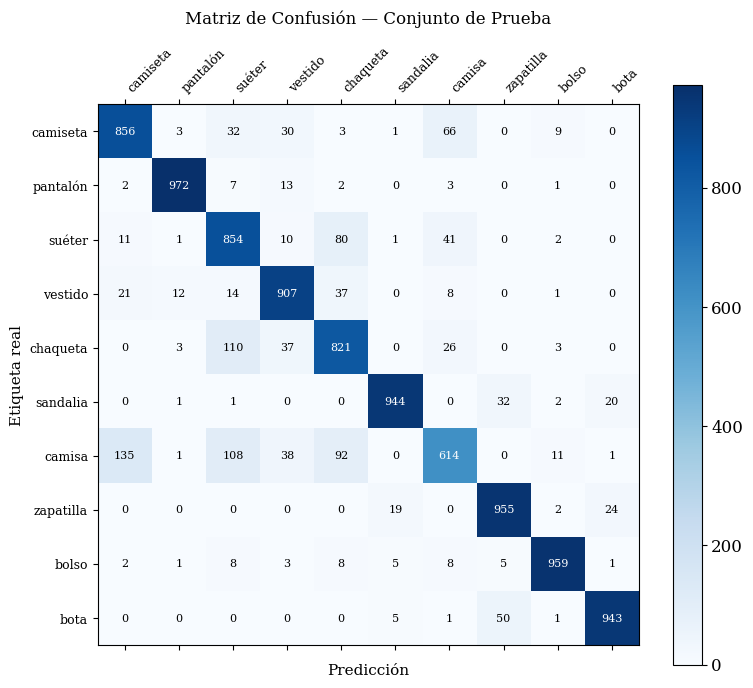

In [12]:
# Matriz de confusión: filas = etiqueta real, columnas = etiqueta predicha
# Un modelo perfecto tendría valores solo en la diagonal principal.
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.matshow(cm, cmap='Blues')         # Color más oscuro = más predicciones en esa celda
plt.colorbar(im, ax=ax)

# Etiquetas de los ejes con nombres de clases
class_names = [classes[i] for i in range(10)]
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='left', fontsize=9)
ax.set_yticklabels(class_names, fontsize=9)
ax.set_xlabel('Predicción', fontsize=11, labelpad=10)
ax.set_ylabel('Etiqueta real', fontsize=11)
ax.set_title('Matriz de Confusión — Conjunto de Prueba', fontsize=12, pad=15)

# Anotamos los valores numéricos en cada celda
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8, color=color)

plt.tight_layout()
plt.show()

---
## 8. (Extra) Red Neuronal Convolucional (CNN)

> Se recomienda correr esta sección en Google Colaboratory con aceleración GPU activada.

### ¿Por qué una DNN no es ideal para imágenes?

Como discutimos en clase, usar una red Fully-Connected para imágenes tiene dos problemas fundamentales:

1. **Pérdida de contexto espacial**: al aplanar la imagen a un vector, la red no sabe qué píxeles están cerca y cuáles están lejos. Dos píxeles adyacentes reciben el mismo tratamiento que dos píxeles en extremos opuestos de la imagen.

2. **Explosión de parámetros**: una imagen de 256×256 con una primera capa de 2048 neuronas requiere 256×256×2048 ≈ **134 millones de parámetros** solo en la primera capa.

### La solución: Convolución

Una CNN aplica **filtros (kernels)** que se deslizan sobre la imagen, detectando patrones locales:

$$\text{Output}[i,j] = \sum_{m=0}^{K-1} \sum_{n=0}^{K-1} \text{Input}[i+m,\, j+n] \cdot \text{Filtro}[m,n]$$

El tamaño de salida de una capa convolucional es:

$$H_{out} = \frac{H_{in} + 2p - K}{s} + 1, \quad W_{out} = \frac{W_{in} + 2p - K}{s} + 1$$

donde $K$ = kernel size, $p$ = padding, $s$ = stride.

### Ventajas clave de las CNNs

- **Compartición de parámetros**: el mismo filtro se aplica en todas las posiciones → muchos menos parámetros que una FC layer
- **Invarianza traslacional**: detecta el mismo patrón (ej: borde) sin importar dónde aparezca
- **Preserva estructura espacial**: opera sobre la imagen 2D, no sobre un vector plano

### Arquitectura CNN

```
Input(28×28×1) → Conv2D(16 filtros, 3×3) → MaxPool(2×2) → Flatten → Dense(64) → Dense(10)
```

- **Conv2D**: aprende 16 filtros de 3×3 — cada uno detecta un patrón visual diferente
- **MaxPool2D**: reduce la resolución espacial tomando el máximo en ventanas 2×2 → comprime la representación y añade invarianza a pequeñas traslaciones
- **Flatten**: convierte el tensor 3D resultante en un vector para la clasificación final

---

In [13]:
# =============================================================================
# CNN con Keras
# Arquitectura: Input(28×28×1) → Conv2D(16,3×3,tanh) → MaxPool(2×2)
#               → Flatten → Dense(64,tanh) → Dense(10,softmax)
# =============================================================================
conv_model = keras.Sequential([

    # Capa convolucional: 16 filtros de 3×3 píxeles
    # input_shape=(28,28,1): altura × ancho × canales (1 = escala de grises)
    # Cada filtro aprende a detectar un patrón visual distinto (bordes, texturas, etc.)
    # Parámetros: 16 × (3×3×1 + 1_bias) = 160  ← muy pocos vs. Dense
    keras.layers.Conv2D(
        16,                   # Número de filtros (feature maps)
        (3, 3),               # Tamaño del kernel: 3×3 píxeles
        input_shape=(28, 28, 1),  # (H, W, Canales)
        activation='tanh'     # Activación no-lineal tras la convolución
    ),

    # MaxPooling: reduce espacialmente tomando el máximo en ventanas 2×2
    # 26×26 → 13×13  (sin padding: H_out = H_in - K + 1 = 26 - 2 + 1 = 13)
    # Reduce parámetros y añade ligera invarianza a traslaciones
    keras.layers.MaxPool2D((2, 2)),

    # Flatten: convierte el tensor (13, 13, 16) en un vector (2704,)
    # Necesario para conectar las capas convolucionales con las Dense
    keras.layers.Flatten(),

    # Capa fully-connected: extrae features de alto nivel a partir del mapa de features
    keras.layers.Dense(
        64,
        activation='tanh',
        kernel_regularizer=keras.regularizers.l2(1e-5)
    ),

    # Capa de salida: 10 neuronas + Softmax → probabilidades de clase
    keras.layers.Dense(
        10,
        activation='softmax',
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )
])

# Inspeccionamos la arquitectura: observa cómo los shapes cambian a través de las capas
conv_model.summary()

c:\Users\yomin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,930 (679.41 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compilamos la CNN con la misma configuración que la DNN
conv_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0008),  # lr ligeramente mayor para CNN
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('CNN compilada exitosamente.')

CNN compilada exitosamente.


In [15]:
%%time
# IMPORTANTE: la CNN espera imágenes en formato (muestras, alto, ancho, canales)
# Debemos reformatear X de (N, 784) a (N, 28, 28, 1):
# - reshape(-1, 28, 28, 1): -1 infiere N automáticamente, 1 = canal de escala de grises
conv_model.fit(
    X_train.reshape(-1, 28, 28, 1),          # (50000, 28, 28, 1)
    y_train,
    batch_size=512,                           # Batch más pequeño que la DNN (CNNs usan más memoria)
    epochs=50,                                # 50 épocas — las CNNs convergen más rápido
    validation_data=(X_val.reshape(-1, 28, 28, 1), y_val)
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7627 - loss: 0.7231 - val_accuracy: 0.8303 - val_loss: 0.4906
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8436 - loss: 0.4523 - val_accuracy: 0.8598 - val_loss: 0.4166
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8606 - loss: 0.4013 - val_accuracy: 0.8676 - val_loss: 0.3880
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8724 - loss: 0.3674 - val_accuracy: 0.8797 - val_loss: 0.3598
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8799 - loss: 0.3437 - val_accuracy: 0.8825 - val_loss: 0.3446
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8865 - loss: 0.3286 - val_accuracy: 0.8861 - val_loss: 0.3350
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8883 - loss: 0.3185 - val_accuracy: 0.8877 - val_loss: 0.3275
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8945 - loss: 0.3041 - val_accuracy: 0.8950 - v

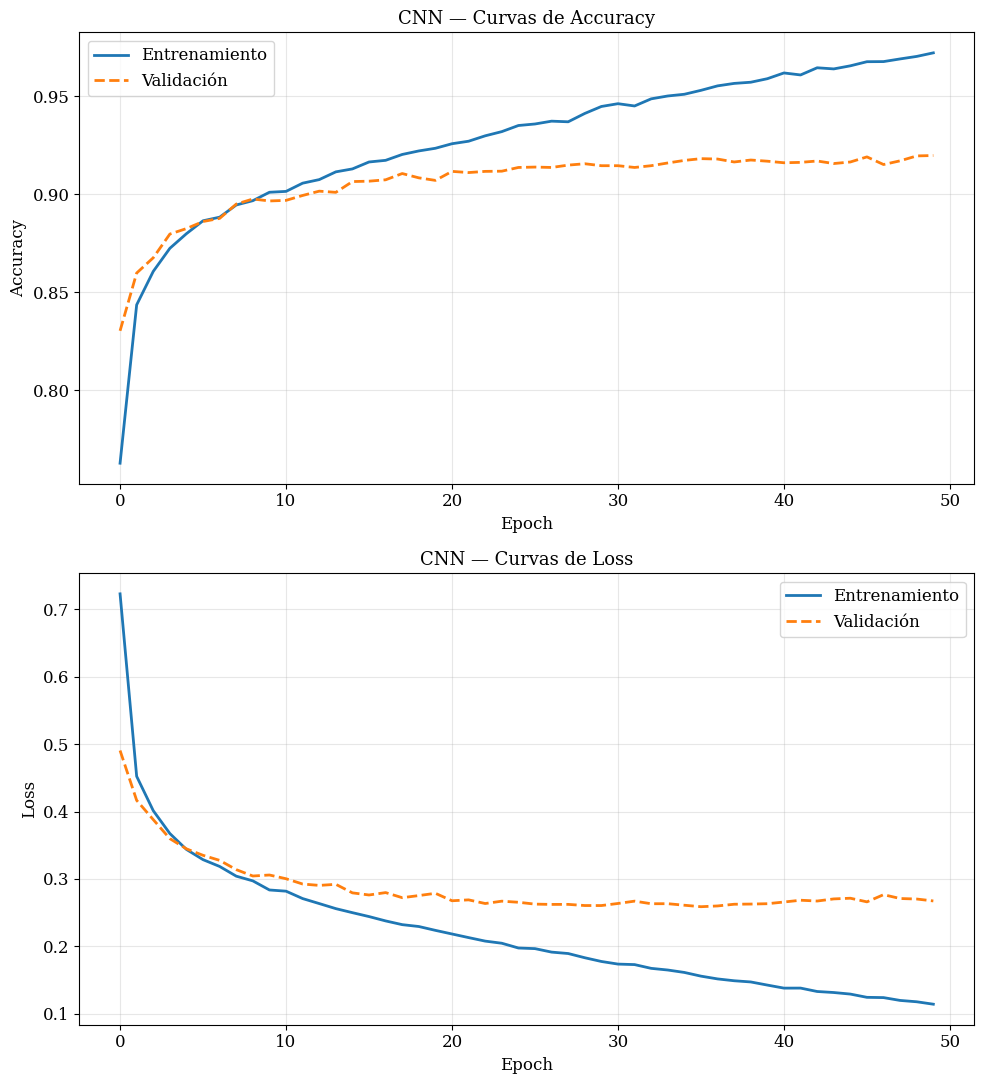

In [16]:
# Curvas de aprendizaje de la CNN
history_cnn = conv_model.history.history

fig, ax = plt.subplots(2, 1, figsize=(10, 11))

ax[0].set_title('CNN — Curvas de Accuracy', size=13)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].plot(history_cnn['accuracy'],     label='Entrenamiento', linewidth=2)
ax[0].plot(history_cnn['val_accuracy'], label='Validación',    linewidth=2, linestyle='--')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].set_title('CNN — Curvas de Loss', size=13)
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].plot(history_cnn['loss'],     label='Entrenamiento', linewidth=2)
ax[1].plot(history_cnn['val_loss'], label='Validación',    linewidth=2, linestyle='--')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Evaluación final de la CNN sobre el conjunto de prueba
print('--- Evaluación CNN sobre conjunto de PRUEBA ---')
cnn_loss, cnn_acc = conv_model.evaluate(
    X_test.reshape(-1, 28, 28, 1),   # Mismo reshape que en entrenamiento
    y_test,
    verbose=1
)
print(f'\nAccuracy CNN : {cnn_acc:.4f}  ({cnn_acc*100:.2f}%)')

--- Evaluación CNN sobre conjunto de PRUEBA ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9110 - loss: 0.2806

Accuracy CNN : 0.9110  (91.10%)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


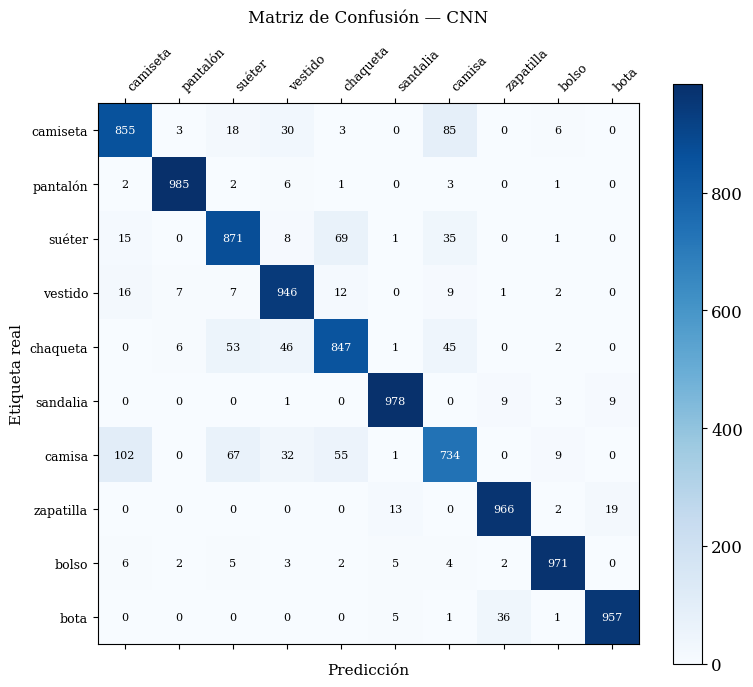

In [18]:
# Matriz de confusión de la CNN
y_pred_cnn = np.argmax(
    conv_model.predict(X_test.reshape(-1, 28, 28, 1)),
    axis=-1
)

cm_cnn = confusion_matrix(y_test, y_pred_cnn)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.matshow(cm_cnn, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels([classes[i] for i in range(10)], rotation=45, ha='left', fontsize=9)
ax.set_yticklabels([classes[i] for i in range(10)], fontsize=9)
ax.set_xlabel('Predicción', fontsize=11, labelpad=10)
ax.set_ylabel('Etiqueta real', fontsize=11)
ax.set_title('Matriz de Confusión — CNN', fontsize=12, pad=15)
for i in range(10):
    for j in range(10):
        color = 'white' if cm_cnn[i, j] > cm_cnn.max() / 2 else 'black'
        ax.text(j, i, str(cm_cnn[i, j]), ha='center', va='center', fontsize=8, color=color)
plt.tight_layout()
plt.show()

---
## 9. Conclusiones y Comparativa

### Resultados esperados

| Modelo | Parámetros | Accuracy en prueba (aprox.) |
|--------|-----------|-----------------------------|
| DNN Keras (4 capas ocultas, tanh + L2) | ~130,000 | ~88-90% |
| **CNN Keras** (Conv2D + MaxPool + Dense) | ~175,000 | **~90-92%** |

La CNN supera a la DNN con un número similar de parámetros porque **preserva la estructura espacial** de la imagen, tal como vimos en clase.

### Keras vs PyTorch — Resumen

| Aspecto | PyTorch (`MyfirstDeepNN`) | Keras (`Clasificación con DNN`) |
|---------|--------------------------|----------------------------------|
| Definición del modelo | Clase Python + `forward()` | `Sequential([...])` |
| Training loop | Manual (5 pasos explícitos) | `model.fit()` automático |
| Evaluación | Loop manual + `torch.no_grad()` | `model.evaluate()` |
| Historial de métricas | Manual (listas propias) | `model.history.history` |
| Flexibilidad | Muy alta | Media-alta |
| Velocidad de prototipado | Media | Alta |

### Experimentos sugeridos

- **Cambia la activación**: reemplaza `tanh` por `relu` en la DNN y compara accuracy y velocidad de convergencia
- **Añade Dropout**: inserta `keras.layers.Dropout(0.3)` entre las capas Dense para reducir overfitting
- **Early Stopping**: usa `keras.callbacks.EarlyStopping(patience=10)` para detener el entrenamiento automáticamente
- **Más filtros en la CNN**: cambia 16 → 32 filtros y observa el impacto en accuracy y tiempo
- **Batch Normalization**: agrega `keras.layers.BatchNormalization()` y observa la estabilidad del entrenamiento